# UNIVERSIDAD AUTÓNOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente

**Curso:** Machine y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** Carlos Daniel Torres Macias 
**Semestre:** Enero-Junio del 2026

---

# Práctica No. 32 – Series de Tiempo en Python

En esta práctica se obtienen **5 series de tiempo reales** de distintas fuentes públicas en Internet y se grafican usando Python con `matplotlib`, `pandas` y `yfinance`.

| # | Serie de Tiempo | Fuente |
|---|----------------|--------|
| 1 | Precio de cierre de Apple (AAPL) | Yahoo Finance |
| 2 | Precio de cierre de Tesla (TSLA) | Yahoo Finance |
| 3 | Precio del Bitcoin (BTC-USD) | Yahoo Finance |
| 4 | Tipo de cambio USD/MXN | Yahoo Finance |
| 5 | Precio del petróleo (Crude Oil Futures) | Yahoo Finance |

---
## Paso 1: Instalación e importación de librerías

In [1]:
# Instalar yfinance si no está disponible
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Estilo visual para las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Librerías cargadas correctamente.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Librerías cargadas correctamente.


---
## Paso 2: Descarga de las 5 series de tiempo desde Yahoo Finance

In [4]:
# Período de análisis: últimos 2 años
inicio = '2023-01-01'
fin    = '2025-01-01'

# Diccionario: ticker -> nombre descriptivo
series = {
    'AAPL'  : 'Apple Inc. (AAPL)',
    'TSLA'  : 'Tesla Inc. (TSLA)',
    'BTC-USD': 'Bitcoin (BTC-USD)',
    'MXN=X' : 'USD/MXN Tipo de Cambio',
    'CL=F'  : 'Petróleo Crudo (WTI Futures)'
}

datos = {}
for ticker, nombre in series.items():
    df = yf.download(ticker, start=inicio, end=fin, progress=False, auto_adjust=True)
    # yfinance moderno puede devolver MultiIndex en columnas; .squeeze() lo aplana a Series
    close = df['Close'].squeeze()
    # Si aún fuera DataFrame (caso extremo), tomar la primera columna
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = ticker
    datos[ticker] = close
    print(f'  ✅ {nombre}: {len(df)} observaciones descargadas')

print('\n📦 Descarga completada.')

  ✅ Apple Inc. (AAPL): 502 observaciones descargadas
  ✅ Tesla Inc. (TSLA): 502 observaciones descargadas
  ✅ Bitcoin (BTC-USD): 731 observaciones descargadas
  ✅ USD/MXN Tipo de Cambio: 522 observaciones descargadas
  ✅ Petróleo Crudo (WTI Futures): 502 observaciones descargadas

📦 Descarga completada.


---
## Paso 3: Vista previa de los datos

In [5]:
# Construir un DataFrame unificado usando pd.concat (más robusto con yfinance moderno)
df_all = pd.concat(datos.values(), axis=1)
df_all.columns = list(series.values())
print('Primeras filas del DataFrame:')
display(df_all.head())

print('\nEstadísticas descriptivas:')
display(df_all.describe().round(2))

Primeras filas del DataFrame:


,Apple Inc. (AAPL),Tesla Inc. (TSLA),Bitcoin (BTC-USD),USD/MXN Tipo de Cambio,Petróleo Crudo (WTI Futures)
Date,,,,,
2023-01-01,NaN,NaN,16625.080078,NaN,NaN
2023-01-02,NaN,NaN,16688.470703,19.446600,NaN
2023-01-03,122.982719,108.099998,16679.857422,19.458799,76.930000
2023-01-04,124.251205,113.639999,16863.238281,19.407600,72.839996
2023-01-05,122.933556,110.339996,16836.736328,19.386801,73.669998



Estadísticas descriptivas:


,Apple Inc. (AAPL),Tesla Inc. (TSLA),Bitcoin (BTC-USD),USD/MXN Tipo de Cambio,Petróleo Crudo (WTI Futures)
count,502.00,502.00,731.00,522.00,502.00
mean,187.90,224.07,47437.16,18.02,76.67
std,28.06,58.66,21675.09,1.13,5.68
min,122.93,108.10,16625.08,16.31,65.75
25%,169.79,183.25,27778.73,17.07,71.84
50%,183.14,216.06,42658.67,17.78,76.78
75%,212.44,251.36,64148.89,18.78,80.60
max,257.38,479.86,106140.60,20.65,93.68


---
## Serie 1: Precio de Cierre – Apple Inc. (AAPL)

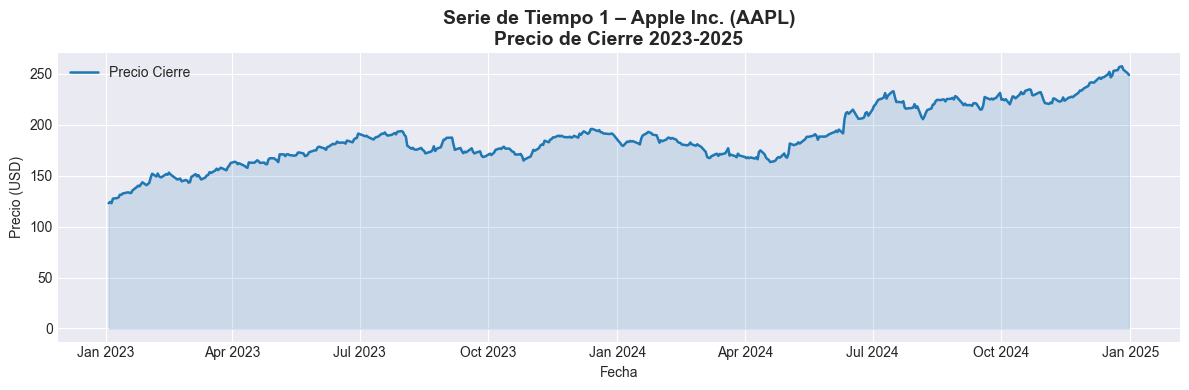

Figura guardada: serie1_AAPL.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(datos['AAPL'].index, datos['AAPL'].values,
        color='#1f77b4', linewidth=1.8, label='Precio Cierre')
ax.fill_between(datos['AAPL'].index, datos['AAPL'].values,
                alpha=0.15, color='#1f77b4')

ax.set_title('Serie de Tiempo 1 – Apple Inc. (AAPL)\nPrecio de Cierre 2023-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig('serie1_AAPL.png', dpi=120)
plt.show()
print('Figura guardada: serie1_AAPL.png')

---
## Serie 2: Precio de Cierre – Tesla Inc. (TSLA)

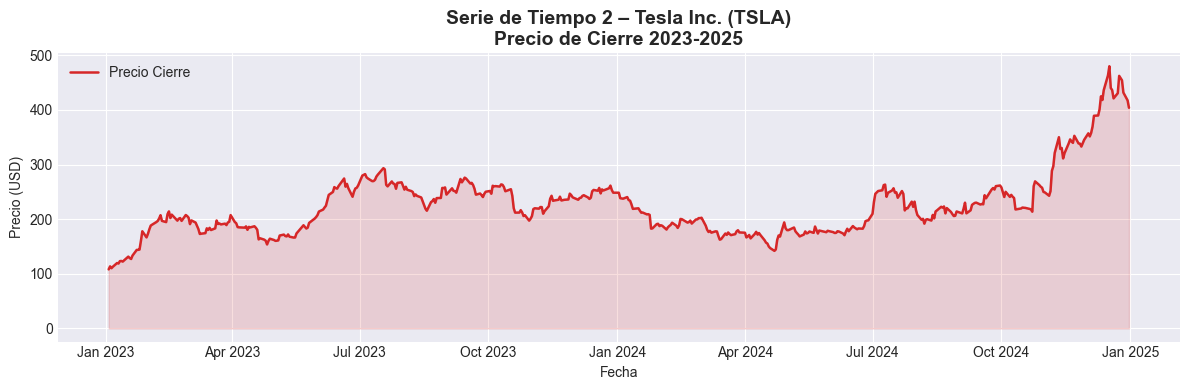

Figura guardada: serie2_TSLA.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(datos['TSLA'].index, datos['TSLA'].values,
        color='#d62728', linewidth=1.8, label='Precio Cierre')
ax.fill_between(datos['TSLA'].index, datos['TSLA'].values,
                alpha=0.15, color='#d62728')

ax.set_title('Serie de Tiempo 2 – Tesla Inc. (TSLA)\nPrecio de Cierre 2023-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig('serie2_TSLA.png', dpi=120)
plt.show()
print('Figura guardada: serie2_TSLA.png')

---
## Serie 3: Precio – Bitcoin (BTC-USD)

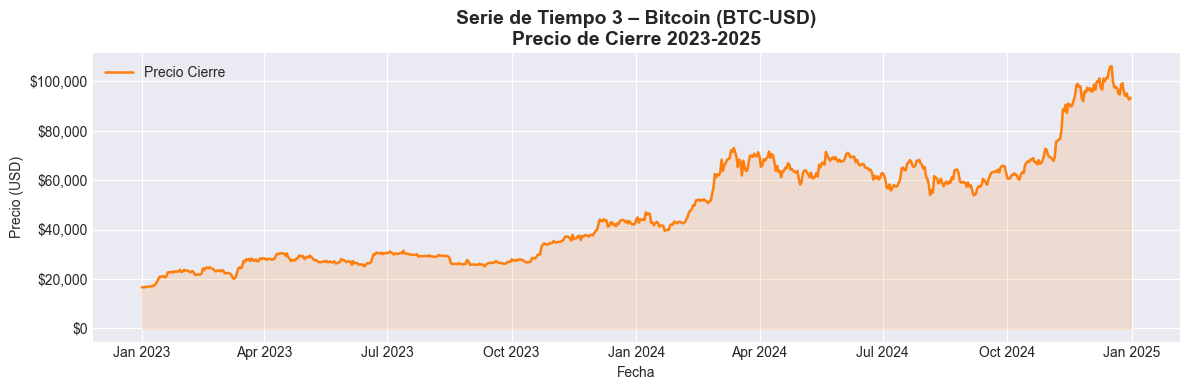

Figura guardada: serie3_BTC.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(datos['BTC-USD'].index, datos['BTC-USD'].values,
        color='#ff7f0e', linewidth=1.8, label='Precio Cierre')
ax.fill_between(datos['BTC-USD'].index, datos['BTC-USD'].values,
                alpha=0.15, color='#ff7f0e')

ax.set_title('Serie de Tiempo 3 – Bitcoin (BTC-USD)\nPrecio de Cierre 2023-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig('serie3_BTC.png', dpi=120)
plt.show()
print('Figura guardada: serie3_BTC.png')

---
## Serie 4: Tipo de Cambio USD/MXN

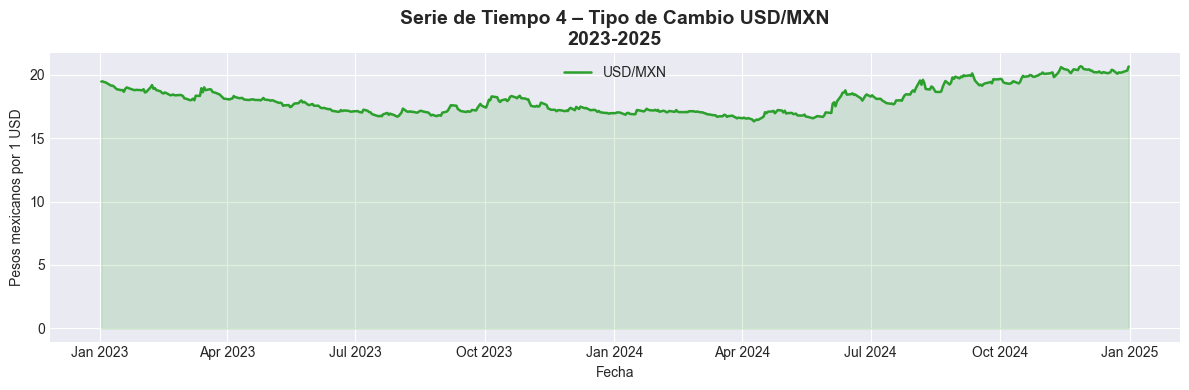

Figura guardada: serie4_USDMXN.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(datos['MXN=X'].index, datos['MXN=X'].values,
        color='#2ca02c', linewidth=1.8, label='USD/MXN')
ax.fill_between(datos['MXN=X'].index, datos['MXN=X'].values,
                alpha=0.15, color='#2ca02c')

ax.set_title('Serie de Tiempo 4 – Tipo de Cambio USD/MXN\n2023-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Pesos mexicanos por 1 USD')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig('serie4_USDMXN.png', dpi=120)
plt.show()
print('Figura guardada: serie4_USDMXN.png')

---
## Serie 5: Precio del Petróleo Crudo (WTI Futures – CL=F)

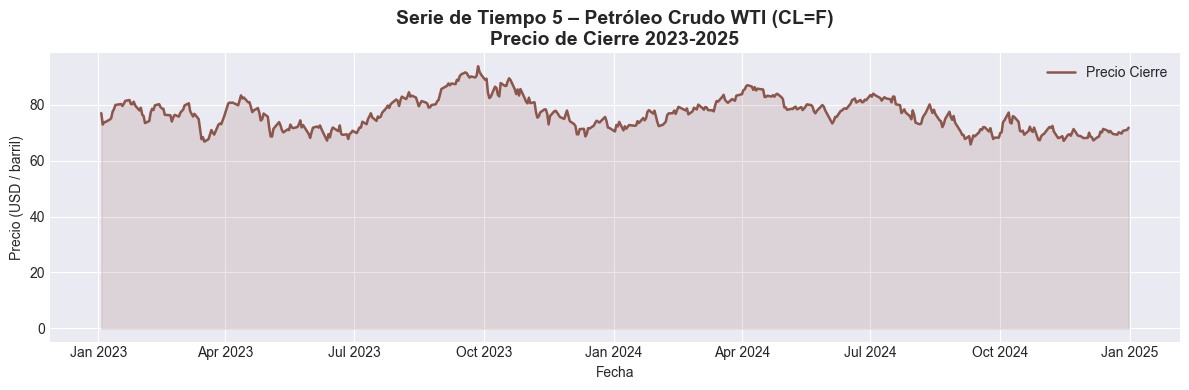

Figura guardada: serie5_Petroleo.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(datos['CL=F'].index, datos['CL=F'].values,
        color='#8c564b', linewidth=1.8, label='Precio Cierre')
ax.fill_between(datos['CL=F'].index, datos['CL=F'].values,
                alpha=0.15, color='#8c564b')

ax.set_title('Serie de Tiempo 5 – Petróleo Crudo WTI (CL=F)\nPrecio de Cierre 2023-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD / barril)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig('serie5_Petroleo.png', dpi=120)
plt.show()
print('Figura guardada: serie5_Petroleo.png')

---
## Paso Final: Panel comparativo de las 5 series (normalizado 0-1)

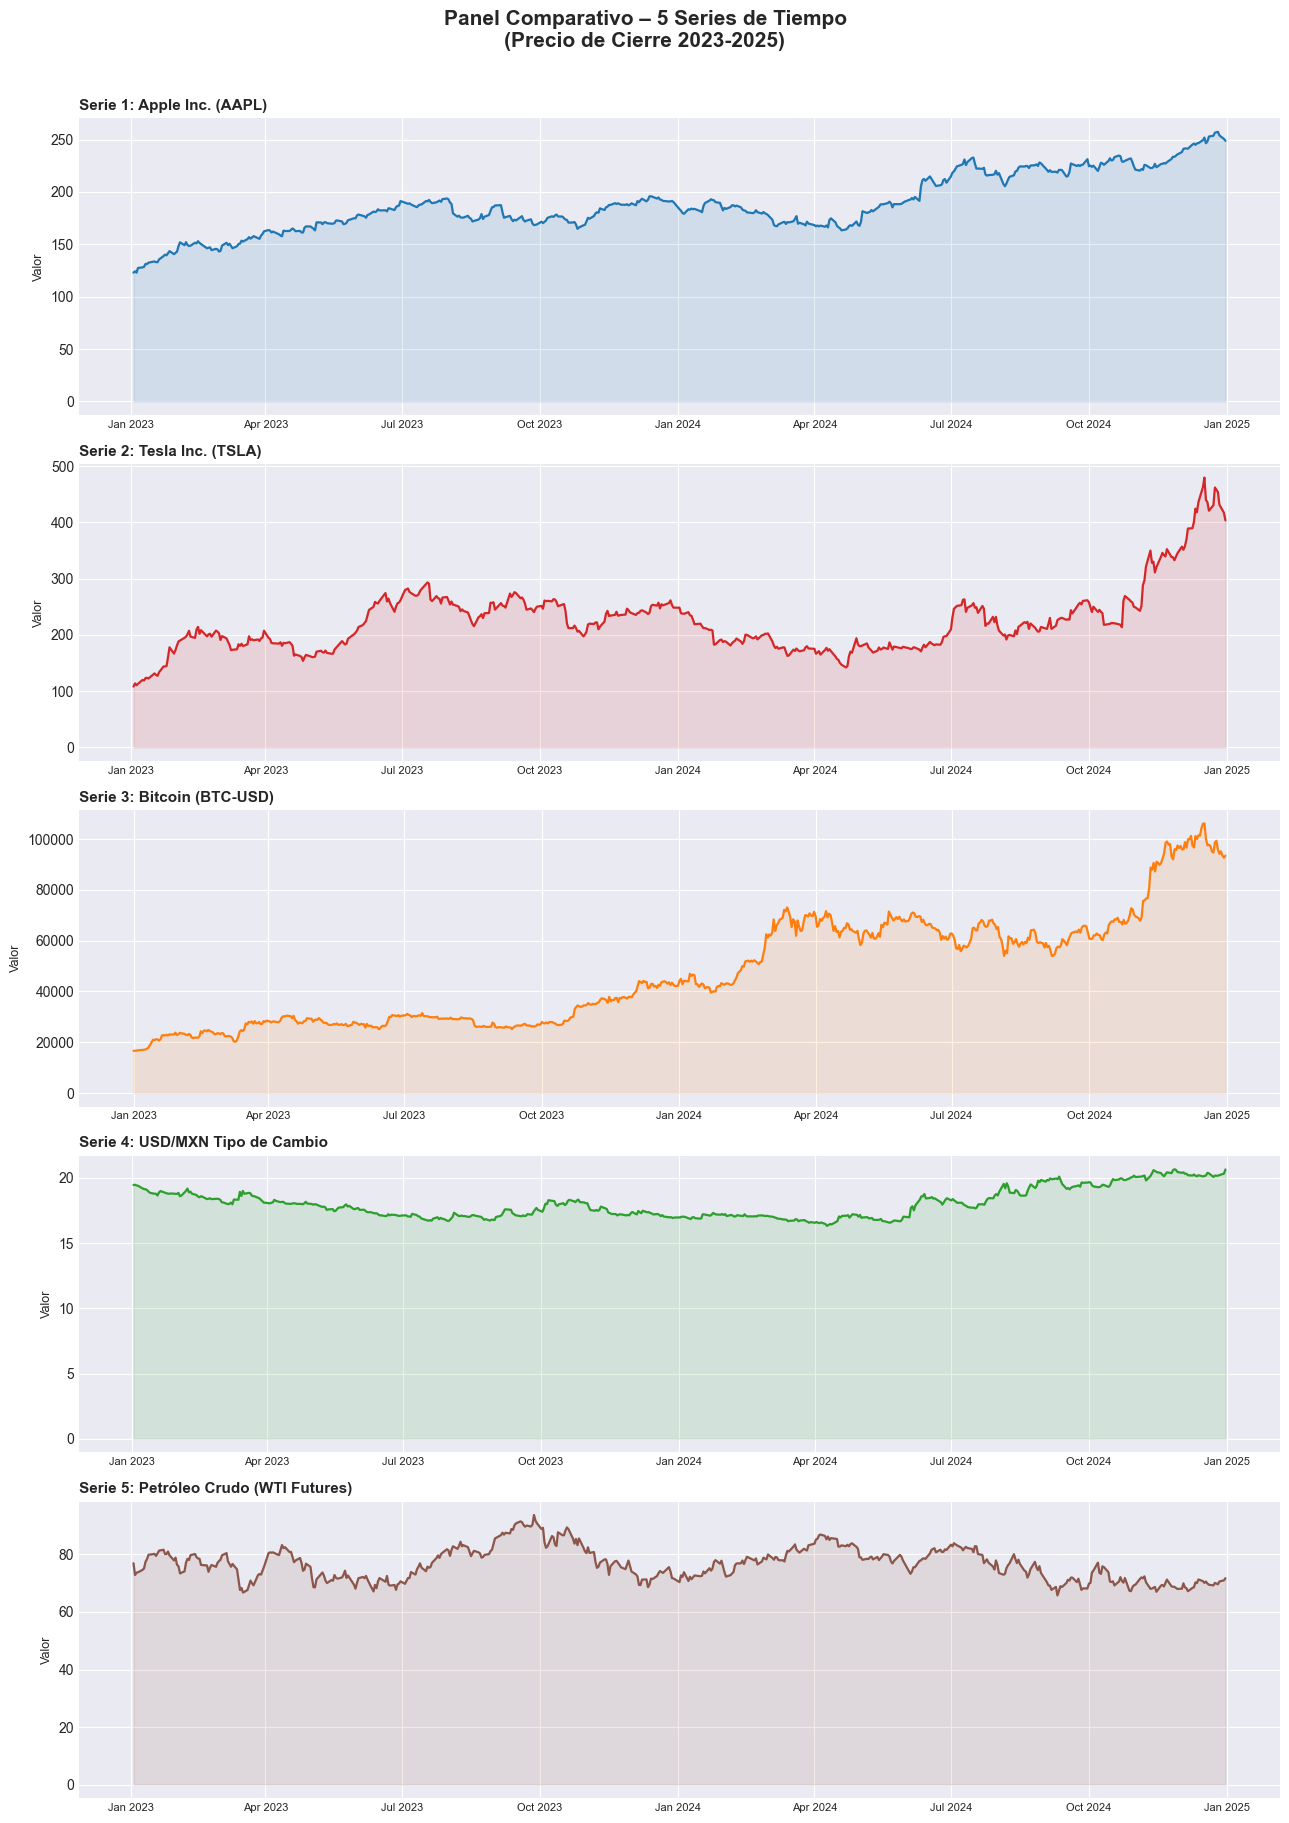

Figura guardada: panel_5_series.png


In [11]:
# Normalización min-max para comparar en la misma escala
def normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

colores = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c', '#8c564b']
tickers = list(series.keys())
nombres = list(series.values())

fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=False)
fig.suptitle('Panel Comparativo – 5 Series de Tiempo\n(Precio de Cierre 2023-2025)',
             fontsize=15, fontweight='bold', y=1.01)

for i, (ticker, nombre, color, ax) in enumerate(zip(tickers, nombres, colores, axes)):
    serie = datos[ticker].dropna()
    ax.plot(serie.index, serie.values, color=color, linewidth=1.6)
    ax.fill_between(serie.index, serie.values, alpha=0.12, color=color)
    ax.set_ylabel('Valor', fontsize=9)
    ax.set_title(f'Serie {i+1}: {nombre}', fontsize=11, fontweight='bold', loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('panel_5_series.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figura guardada: panel_5_series.png')

---
# CONCLUSIONES

En esta práctica se obtuvieron **5 series de tiempo reales** directamente desde Internet usando la librería `yfinance` (Yahoo Finance) y se graficaron con `matplotlib` y `pandas` en Python.

- **Apple (AAPL):** Muestra una tendencia alcista sostenida a lo largo del período, con baja volatilidad relativa.
- **Tesla (TSLA):** Alta volatilidad; presenta fluctuaciones abruptas que reflejan la sensibilidad de la acción a noticias y resultados corporativos.
- **Bitcoin (BTC-USD):** Comportamiento altamente no estacionario con un fuerte rally en el segundo año del período.
- **USD/MXN:** Refleja la depreciación gradual del peso mexicano frente al dólar, con eventos de volatilidad puntual.
- **Petróleo WTI (CL=F):** Oscilación dentro de un rango con tendencia descendente, afectada por factores geopolíticos y de oferta.

El análisis visual de series de tiempo es el primer paso esencial antes de aplicar modelos predictivos como ARIMA, LSTM o Prophet.

---
## REFERENCIAS

1. Yahoo Finance (2026). https://finance.yahoo.com/  
2. yfinance Documentation (2026). https://pypi.org/project/yfinance/  
3. McKinney, W. (2022). *Python for Data Analysis*, 3rd ed. O'Reilly Media.  
4. Hunter, J.D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90-95.  
5. Reporte Técnico de PROMIDAT (2025). https://promidat.com/